<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/TradingStrategies/TradingStrategies/Volatility_Breakout_Strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

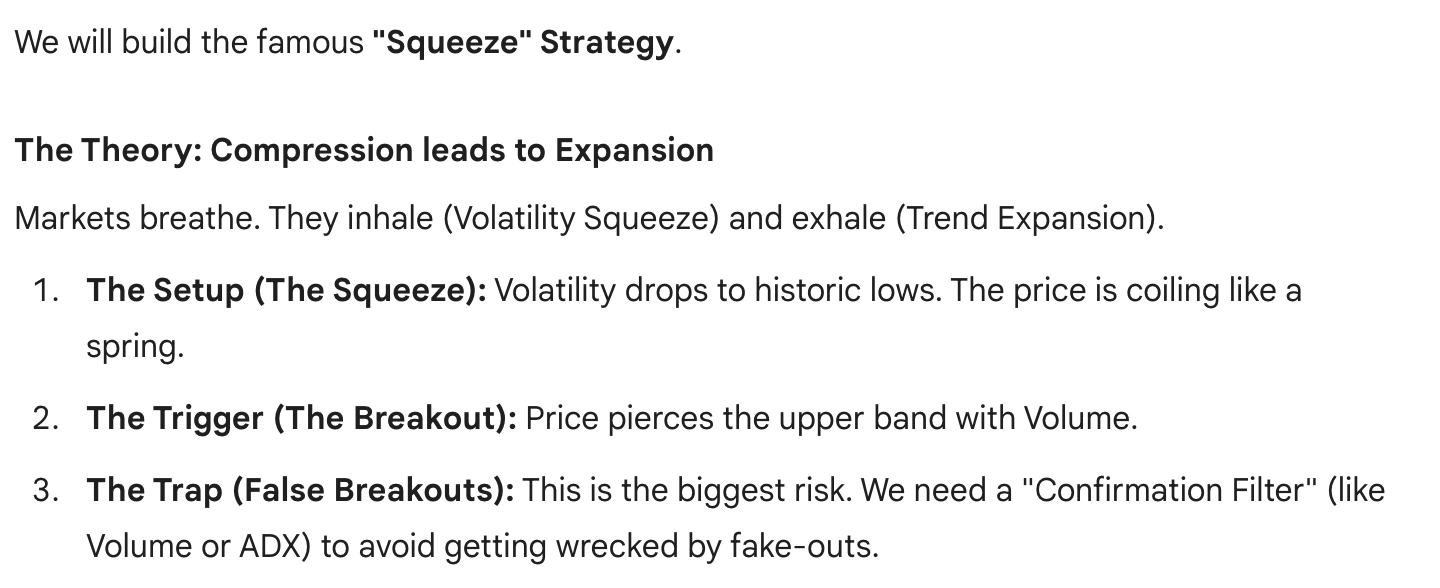

In [17]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# --- CONFIGURATION ---
ticker = 'BTC-USD'
start_date = '2018-01-01'
end_date = '2024-01-01'

print(f"📥 Downloading Data for {ticker}...")
df = yf.download(ticker, start=start_date, end=end_date, progress=False)

📥 Downloading Data for BTC-USD...


/tmp/ipython-input-258752881.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)


In [4]:
# Clean MultiIndex if present (yfinance update quirk)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()
df.head()

Price,Open,High,Low,Close,Volume
Date,,,,,
2018-01-01,14112.200195,14112.200195,13154.700195,13657.200195,10291200000
2018-01-02,13625.000000,15444.599609,13163.599609,14982.099609,16846600192
2018-01-03,14978.200195,15572.799805,14844.500000,15201.000000,16871900160
2018-01-04,15270.700195,15739.700195,14522.200195,15599.200195,21783199744
2018-01-05,15477.200195,17705.199219,15202.799805,17429.500000,23840899072


In [7]:
# --- INDICATOR ENGINEERING ---

# 1. Bollinger Bands (20, 2.0)
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['StdDev'] = df['Close'].rolling(window=20).std()
df['Upper_BB'] = df['SMA_20'] + (2.0 * df['StdDev'])
df['Lower_BB'] = df['SMA_20'] - (2.0 * df['StdDev'])
df.tail()

Price,Open,High,Low,Close,Volume,SMA_20,StdDev,Upper_BB,Lower_BB
Date,,,,,,,,,
2023-12-27,42518.468750,43683.160156,42167.582031,43442.855469,25260941032,42928.051172,931.546543,44791.144259,41064.958085
2023-12-28,43468.199219,43804.781250,42318.550781,42627.855469,22992093014,42851.113867,886.314774,44623.743416,41078.484319
2023-12-29,42614.644531,43124.324219,41424.062500,42099.402344,26000021055,42769.784766,876.383329,44522.551424,41017.018107
2023-12-30,42091.753906,42584.125000,41556.226562,42156.902344,16013925945,42688.644922,852.764274,44394.173470,40983.116374
2023-12-31,42152.097656,42860.937500,41998.253906,42265.187500,16397498810,42739.712695,789.956854,44319.626402,41159.798988


In [10]:
# 2. Keltner Channels (20, 1.5 ATR)
# Calculate ATR first
df['TR'] = np.maximum(df['High'] - df['Low'],
                      np.maximum(abs(df['High'] - df['Close'].shift(1)),
                                 abs(df['Low'] - df['Close'].shift(1))))
df['ATR_20'] = df['TR'].rolling(window=20).mean()

df['Upper_KC'] = df['SMA_20'] + (1.5 * df['ATR_20'])
df['Lower_KC'] = df['SMA_20'] - (1.5 * df['ATR_20'])
df.tail()

Price,Open,High,Low,Close,Volume,SMA_20,StdDev,Upper_BB,Lower_BB,TR,ATR_20,Upper_KC,Lower_KC
Date,,,,,,,,,,,,,
2023-12-27,42518.468750,43683.160156,42167.582031,43442.855469,25260941032,42928.051172,931.546543,44791.144259,41064.958085,1515.578125,1469.448047,45132.223242,40723.879102
2023-12-28,43468.199219,43804.781250,42318.550781,42627.855469,22992093014,42851.113867,886.314774,44623.743416,41078.484319,1486.230469,1464.748633,45048.236816,40653.990918
2023-12-29,42614.644531,43124.324219,41424.062500,42099.402344,26000021055,42769.784766,876.383329,44522.551424,41017.018107,1700.261719,1513.078711,45039.402832,40500.166699
2023-12-30,42091.753906,42584.125000,41556.226562,42156.902344,16013925945,42688.644922,852.764274,44394.173470,40983.116374,1027.898438,1542.406641,45002.254883,40375.034961
2023-12-31,42152.097656,42860.937500,41998.253906,42265.187500,16397498810,42739.712695,789.956854,44319.626402,41159.798988,862.683594,1406.850977,44849.989160,40629.436230


In [11]:
# 3. The "Squeeze" Indicator
# Squeeze is ON when Bollinger Bands are INSIDE Keltner Channels
df['Squeeze_On'] = (df['Lower_BB'] > df['Lower_KC']) & (df['Upper_BB'] < df['Upper_KC'])
df.tail()

Price,Open,High,Low,Close,Volume,SMA_20,StdDev,Upper_BB,Lower_BB,TR,ATR_20,Upper_KC,Lower_KC,Squeeze_On
Date,,,,,,,,,,,,,,
2023-12-27,42518.468750,43683.160156,42167.582031,43442.855469,25260941032,42928.051172,931.546543,44791.144259,41064.958085,1515.578125,1469.448047,45132.223242,40723.879102,True
2023-12-28,43468.199219,43804.781250,42318.550781,42627.855469,22992093014,42851.113867,886.314774,44623.743416,41078.484319,1486.230469,1464.748633,45048.236816,40653.990918,True
2023-12-29,42614.644531,43124.324219,41424.062500,42099.402344,26000021055,42769.784766,876.383329,44522.551424,41017.018107,1700.261719,1513.078711,45039.402832,40500.166699,True
2023-12-30,42091.753906,42584.125000,41556.226562,42156.902344,16013925945,42688.644922,852.764274,44394.173470,40983.116374,1027.898438,1542.406641,45002.254883,40375.034961,True
2023-12-31,42152.097656,42860.937500,41998.253906,42265.187500,16397498810,42739.712695,789.956854,44319.626402,41159.798988,862.683594,1406.850977,44849.989160,40629.436230,True


In [12]:
# 4. Momentum Filter (Don't buy breakouts into resistance)
# Simple RSI or Rate of Change
df['Momentum'] = df['Close'] - df['Close'].shift(20) # Linear Regression Slope is better, but this works

print("✅ Indicators Built.")
df[['Close', 'Upper_BB', 'Upper_KC', 'Squeeze_On']].tail(10)

✅ Indicators Built.


Price,Close,Upper_BB,Upper_KC,Squeeze_On
Date,,,,
2023-12-22,43997.902344,45110.430069,45111.540723,True
2023-12-23,43739.542969,44932.063859,45286.616016,True
2023-12-24,43016.117188,44930.089377,45245.810449,True
2023-12-25,43613.140625,44862.573617,45073.320703,True
2023-12-26,42520.402344,44776.093244,45098.190918,True
2023-12-27,43442.855469,44791.144259,45132.223242,True
2023-12-28,42627.855469,44623.743416,45048.236816,True
2023-12-29,42099.402344,44522.551424,45039.402832,True
2023-12-30,42156.902344,44394.173470,45002.254883,True


In [13]:
# --- TRADING LOGIC ---

# 1. Identify "Squeeze Fired"
# Did we have a squeeze in the last 5 days?
df['Was_Squeezed'] = df['Squeeze_On'].rolling(window=5).max()

# 2. Entry Signals
# Breakout UP + Momentum + Recent Squeeze
df['Long_Signal'] = (df['Close'] > df['Upper_BB']) & \
                    (df['Was_Squeezed'] == 1) & \
                    (df['Momentum'] > 0)

df.tail()

Price,Open,High,Low,Close,Volume,SMA_20,StdDev,Upper_BB,Lower_BB,TR,ATR_20,Upper_KC,Lower_KC,Squeeze_On,Momentum,Was_Squeezed,Long_Signal
Date,,,,,,,,,,,,,,,,,
2023-12-27,42518.468750,43683.160156,42167.582031,43442.855469,25260941032,42928.051172,931.546543,44791.144259,41064.958085,1515.578125,1469.448047,45132.223242,40723.879102,True,150.191406,1.0,False
2023-12-28,43468.199219,43804.781250,42318.550781,42627.855469,22992093014,42851.113867,886.314774,44623.743416,41078.484319,1486.230469,1464.748633,45048.236816,40653.990918,True,-1538.746094,1.0,False
2023-12-29,42614.644531,43124.324219,41424.062500,42099.402344,26000021055,42769.784766,876.383329,44522.551424,41017.018107,1700.261719,1513.078711,45039.402832,40500.166699,True,-1626.582031,1.0,False
2023-12-30,42091.753906,42584.125000,41556.226562,42156.902344,16013925945,42688.644922,852.764274,44394.173470,40983.116374,1027.898438,1542.406641,45002.254883,40375.034961,True,-1622.796875,1.0,False
2023-12-31,42152.097656,42860.937500,41998.253906,42265.187500,16397498810,42739.712695,789.956854,44319.626402,41159.798988,862.683594,1406.850977,44849.989160,40629.436230,True,1021.355469,1.0,False


In [15]:
# 3. Simulation Loop (Need loop for Trailing Stop)
# Vectorized backtesting is hard with dynamic trailing stops
capital = 10000
position = 0 # 0 or 1 (Size)
entry_price = 0
stop_loss = 0
equity_curve = []
trades = [] # Record trade details

dates = df.index
closes = df['Close'].values
highs = df['High'].values
atrs = df['ATR_20'].values
long_signals = df['Long_Signal'].values

for i in range(len(df)):

    # Update Stop Loss (Trailing Logic)
    # If we are long, raise the stop loss if price goes up
    # Stop = Highest High since entry - 3 * ATR
    if position > 0:
        new_stop = highs[i] - (3.0 * atrs[i])
        stop_loss = max(stop_loss, new_stop) # Never lower the stop

    # Check Exit (Hit Stop?)
    if position > 0 and closes[i] < stop_loss:
        # SELL
        pnl = (stop_loss - entry_price) / entry_price # Assume executed at stop
        capital = capital * (1 + pnl)
        position = 0
        trades.append({'Date': dates[i], 'Type': 'SELL', 'Price': stop_loss, 'Capital': capital})

    # Check Entry
    elif position == 0 and long_signals[i]:
        # BUY
        position = 1
        entry_price = closes[i]
        stop_loss = closes[i] - (3.0 * atrs[i]) # Initial Stop
        trades.append({'Date': dates[i], 'Type': 'BUY', 'Price': entry_price, 'Capital': capital})

    # Mark to Market (for equity curve)
    if position > 0:
        current_val = capital * (closes[i] / entry_price)
    else:
        current_val = capital

    equity_curve.append(current_val)

df['Strategy_Eq'] = equity_curve
df['Benchmark_Eq'] = (df['Close'] / df['Close'].iloc[0]) * 10000

df.tail()

Price,Open,High,Low,Close,Volume,SMA_20,StdDev,Upper_BB,Lower_BB,TR,ATR_20,Upper_KC,Lower_KC,Squeeze_On,Momentum,Was_Squeezed,Long_Signal,Strategy_Eq,Benchmark_Eq
Date,,,,,,,,,,,,,,,,,,,
2023-12-27,42518.468750,43683.160156,42167.582031,43442.855469,25260941032,42928.051172,931.546543,44791.144259,41064.958085,1515.578125,1469.448047,45132.223242,40723.879102,True,150.191406,1.0,False,76596.375075,31809.488656
2023-12-28,43468.199219,43804.781250,42318.550781,42627.855469,22992093014,42851.113867,886.314774,44623.743416,41078.484319,1486.230469,1464.748633,45048.236816,40653.990918,True,-1538.746094,1.0,False,75159.405866,31212.733839
2023-12-29,42614.644531,43124.324219,41424.062500,42099.402344,26000021055,42769.784766,876.383329,44522.551424,41017.018107,1700.261719,1513.078711,45039.402832,40500.166699,True,-1626.582031,1.0,False,74227.662468,30825.792799
2023-12-30,42091.753906,42584.125000,41556.226562,42156.902344,16013925945,42688.644922,852.764274,44394.173470,40983.116374,1027.898438,1542.406641,45002.254883,40375.034961,True,-1622.796875,1.0,False,74329.043731,30867.895133
2023-12-31,42152.097656,42860.937500,41998.253906,42265.187500,16397498810,42739.712695,789.956854,44319.626402,41159.798988,862.683594,1406.850977,44849.989160,40629.436230,True,1021.355469,1.0,False,74519.966964,30947.183094


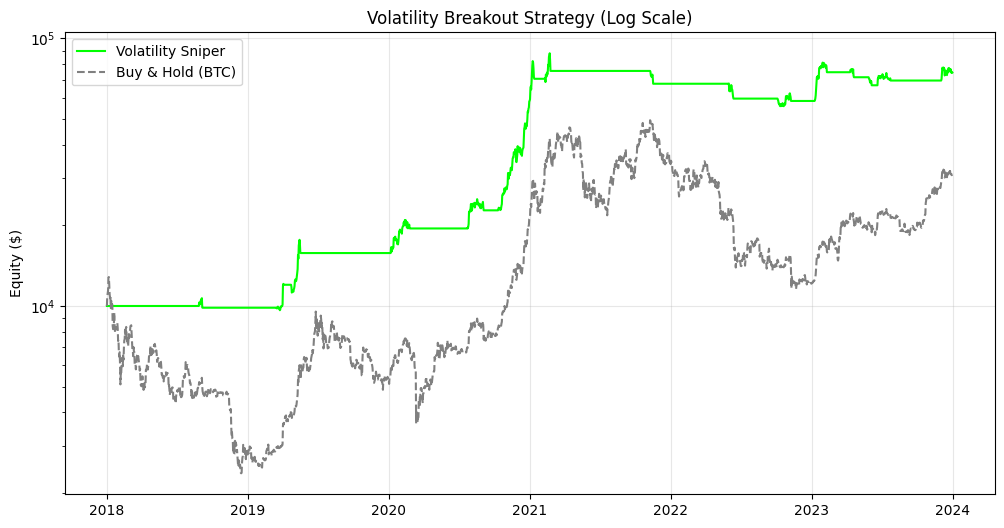

In [16]:
# --- VISUALIZATION ---
plt.figure(figsize=(12, 6))
plt.semilogy(df.index, df['Strategy_Eq'], label='Volatility Sniper', color='lime')
plt.semilogy(df.index, df['Benchmark_Eq'], label='Buy & Hold (BTC)', color='gray', linestyle='--')
plt.title("Volatility Breakout Strategy (Log Scale)")
plt.ylabel("Equity ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
# --- ALPHA AUDIT ---

# Calculate Daily Returns
strat_ret = df['Strategy_Eq'].pct_change().dropna()
bench_ret = df['Benchmark_Eq'].pct_change().dropna()

In [19]:
# 1. Regression
slope, intercept, r, p, err = stats.linregress(bench_ret, strat_ret)

# 2. Key Metrics
beta = slope
alpha = intercept * 252 # Annualized
sharpe = strat_ret.mean() / strat_ret.std() * np.sqrt(252)
max_dd = (df['Strategy_Eq'] / df['Strategy_Eq'].cummax() - 1).min()
win_rate = len([t for t in trades if t['Type'] == 'SELL' and t['Capital'] > 10000]) / len(trades) # Approx check

print("📊 VOLATILITY BREAKOUT AUDIT")
print(f"----------------------------")
print(f"Total Return:       {((df['Strategy_Eq'].iloc[-1]/10000)-1)*100:.2f}%")
print(f"Sharpe Ratio:       {sharpe:.2f}")
print(f"Max Drawdown:       {max_dd*100:.2f}%")
print(f"Beta (vs BTC):      {beta:.2f}")
print(f"Alpha (Annualized): {alpha*100:.2f}%")

📊 VOLATILITY BREAKOUT AUDIT
----------------------------
Total Return:       645.20%
Sharpe Ratio:       1.19
Max Drawdown:       -36.58%
Beta (vs BTC):      0.14
Alpha (Annualized): 21.18%


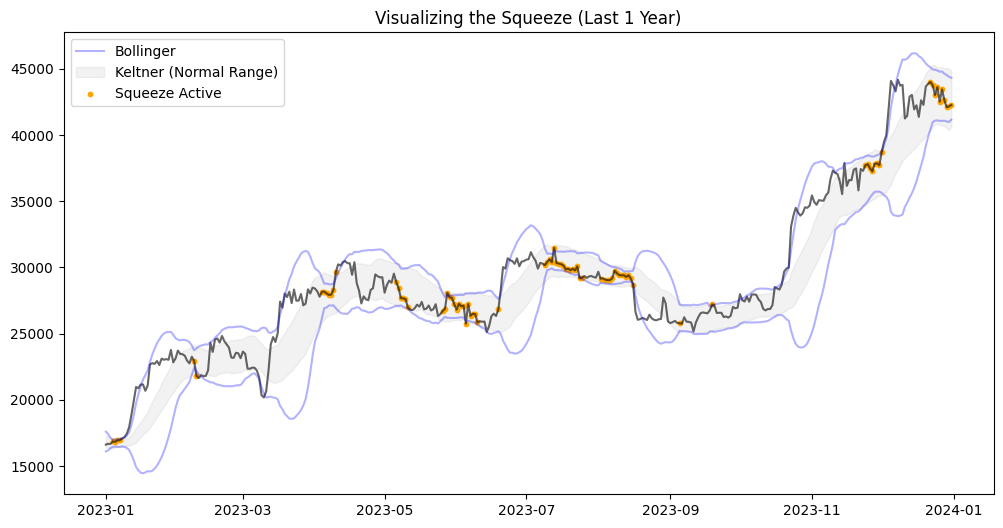

In [20]:
# 3. Trade Analysis Visualization
# Let's see the 'Squeeze' visually
subset = df[-365:] # Last year
plt.figure(figsize=(12, 6))
plt.plot(subset.index, subset['Close'], color='black', alpha=0.6)
plt.plot(subset.index, subset['Upper_BB'], color='blue', alpha=0.3, label='Bollinger')
plt.plot(subset.index, subset['Lower_BB'], color='blue', alpha=0.3)
plt.fill_between(subset.index, subset['Upper_KC'], subset['Lower_KC'], color='gray', alpha=0.1, label='Keltner (Normal Range)')

# Highlight Squeezes
squeeze_periods = subset[subset['Squeeze_On']]
plt.scatter(squeeze_periods.index, squeeze_periods['Close'], color='orange', s=10, label='Squeeze Active')

plt.title("Visualizing the Squeeze (Last 1 Year)")
plt.legend()
plt.show()